# BrushCue Example: Riviera Pop

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/riviera_pop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/riviera-pop

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


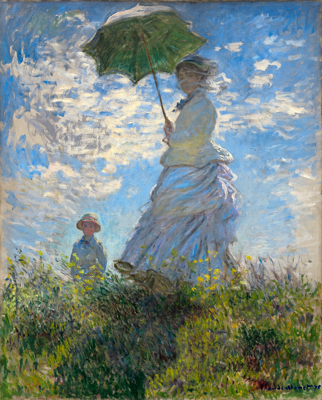

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
base_grade = input_image.l_curve(
    bc.Curve.s_curve(0.5, 1.16, 1.0, 1.0)
).saturation_adjust(1.12)
graded = base_grade.color_transformer_shader(
    "let blue_weight = smoothstep(-0.015, -0.12, input.b);\nlet cyan_weight = blue_weight * smoothstep(0.08, -0.07, input.g);\nlet cobalt_weight = blue_weight * smoothstep(-0.08, 0.04, input.g);\nlet a = input.g - 0.03 * cyan_weight + 0.012 * cobalt_weight;\nlet b = input.b - 0.045 * blue_weight;\nreturn vec4f(input.r, a, b, input.a);",
    "",
    bc.ColorRepresentation.oklab_a(),
    bc.ColorRepresentation.oklab_a(),
    bc.Dictionary.create(),
)
bounds = input_image.bounds()
filtered = graded.crop(bounds)
strength = 1.0
graph = (
    filtered.opacity_scales(strength)
    .blend_alpha(input_image, bc.Transform2.identity())
    .crop(bounds)
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
